In [ ]:
import kagglehub
import os

# 1. Veri setini indir ve indiği kök dizin yolunu 'path' değişkenine al
path = kagglehub.dataset_download("vinjamuripavan/bird-species")

# 2. Klasör yollarını gelen bu 'path' değişkenine bağla
train_dir = os.path.join(path, "train")
valid_dir = os.path.join(path, "valid")
test_dir  = os.path.join(path, "test")

# Kontrol edelim:
print("Train klasör yolu:", train_dir)

100%|██████████| 1.97G/1.97G [00:23<00:00, 89.6MB/s]

Extracting files...


Train klasör yolu: /root/.cache/kagglehub/datasets/vinjamuripavan/bird-species/versions/1/train


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# PyTorch versiyonunu kontrol etmek için (tf.__version__ yerine)
print(torch.__version__)

2.11.0+cu128


In [ ]:
import os
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# 1. 'train' klasörünün gerçek konumunu otomatik olarak bulalım
for root, dirs, files in os.walk(path):
    if "train" in dirs:
        base_dir = root
        break

train_dir = os.path.join(base_dir, "train")
valid_dir = os.path.join(base_dir, "valid")
test_dir  = os.path.join(base_dir, "test")

print("Bulunan Doğru Train Yolu:", train_dir)

# 2. Parametreler ve Temel Dönüşüm
image_size = (224, 224)
batch_size = 64

basic_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor()
])

# 3. Klasörlerden Verilerin Yüklenmesi (Dataset)
train_dataset = datasets.ImageFolder(root=train_dir, transform=basic_transform)
val_dataset   = datasets.ImageFolder(root=valid_dir, transform=basic_transform)
test_dataset  = datasets.ImageFolder(root=test_dir,  transform=basic_transform)

# 4. Batch ve Shuffle Ayarları (DataLoader)
train_ds = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_ds   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_ds  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

print("\nVeri seti başarıyla yüklendi!")
print(f"Eğitim görsel sayısı: {len(train_dataset)}")
print(f"Toplam sınıf (kuş türü) sayısı: {len(train_dataset.classes)}")

Bulunan Doğru Train Yolu: /root/.cache/kagglehub/datasets/vinjamuripavan/bird-species/versions/1/BIRDS 525 SPECIES/train

Veri seti başarıyla yüklendi!
Eğitim görsel sayısı: 84635
Toplam sınıf (kuş türü) sayısı: 525


In [ ]:
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

def visualize_dataset(dataloader: DataLoader, classes: list):
    plt.figure(figsize=(24, 18))

    # 1. İlk batch'i alıyoruz
    images, labels = next(iter(dataloader))

    # 2. Batch içerisindeki ilk 64 görseli çizdiriyoruz
    for i in range(min(64, len(images))):
        plt.subplot(8, 8, i + 1)

        # PyTorch (C, H, W) boyutunu Matplotlib (H, W, C) boyutuna getiriyoruz
        img = images[i].permute(1, 2, 0).numpy()

        plt.imshow(img)
        plt.title(classes[labels[i].item()])
        plt.axis('off')

    plt.show()

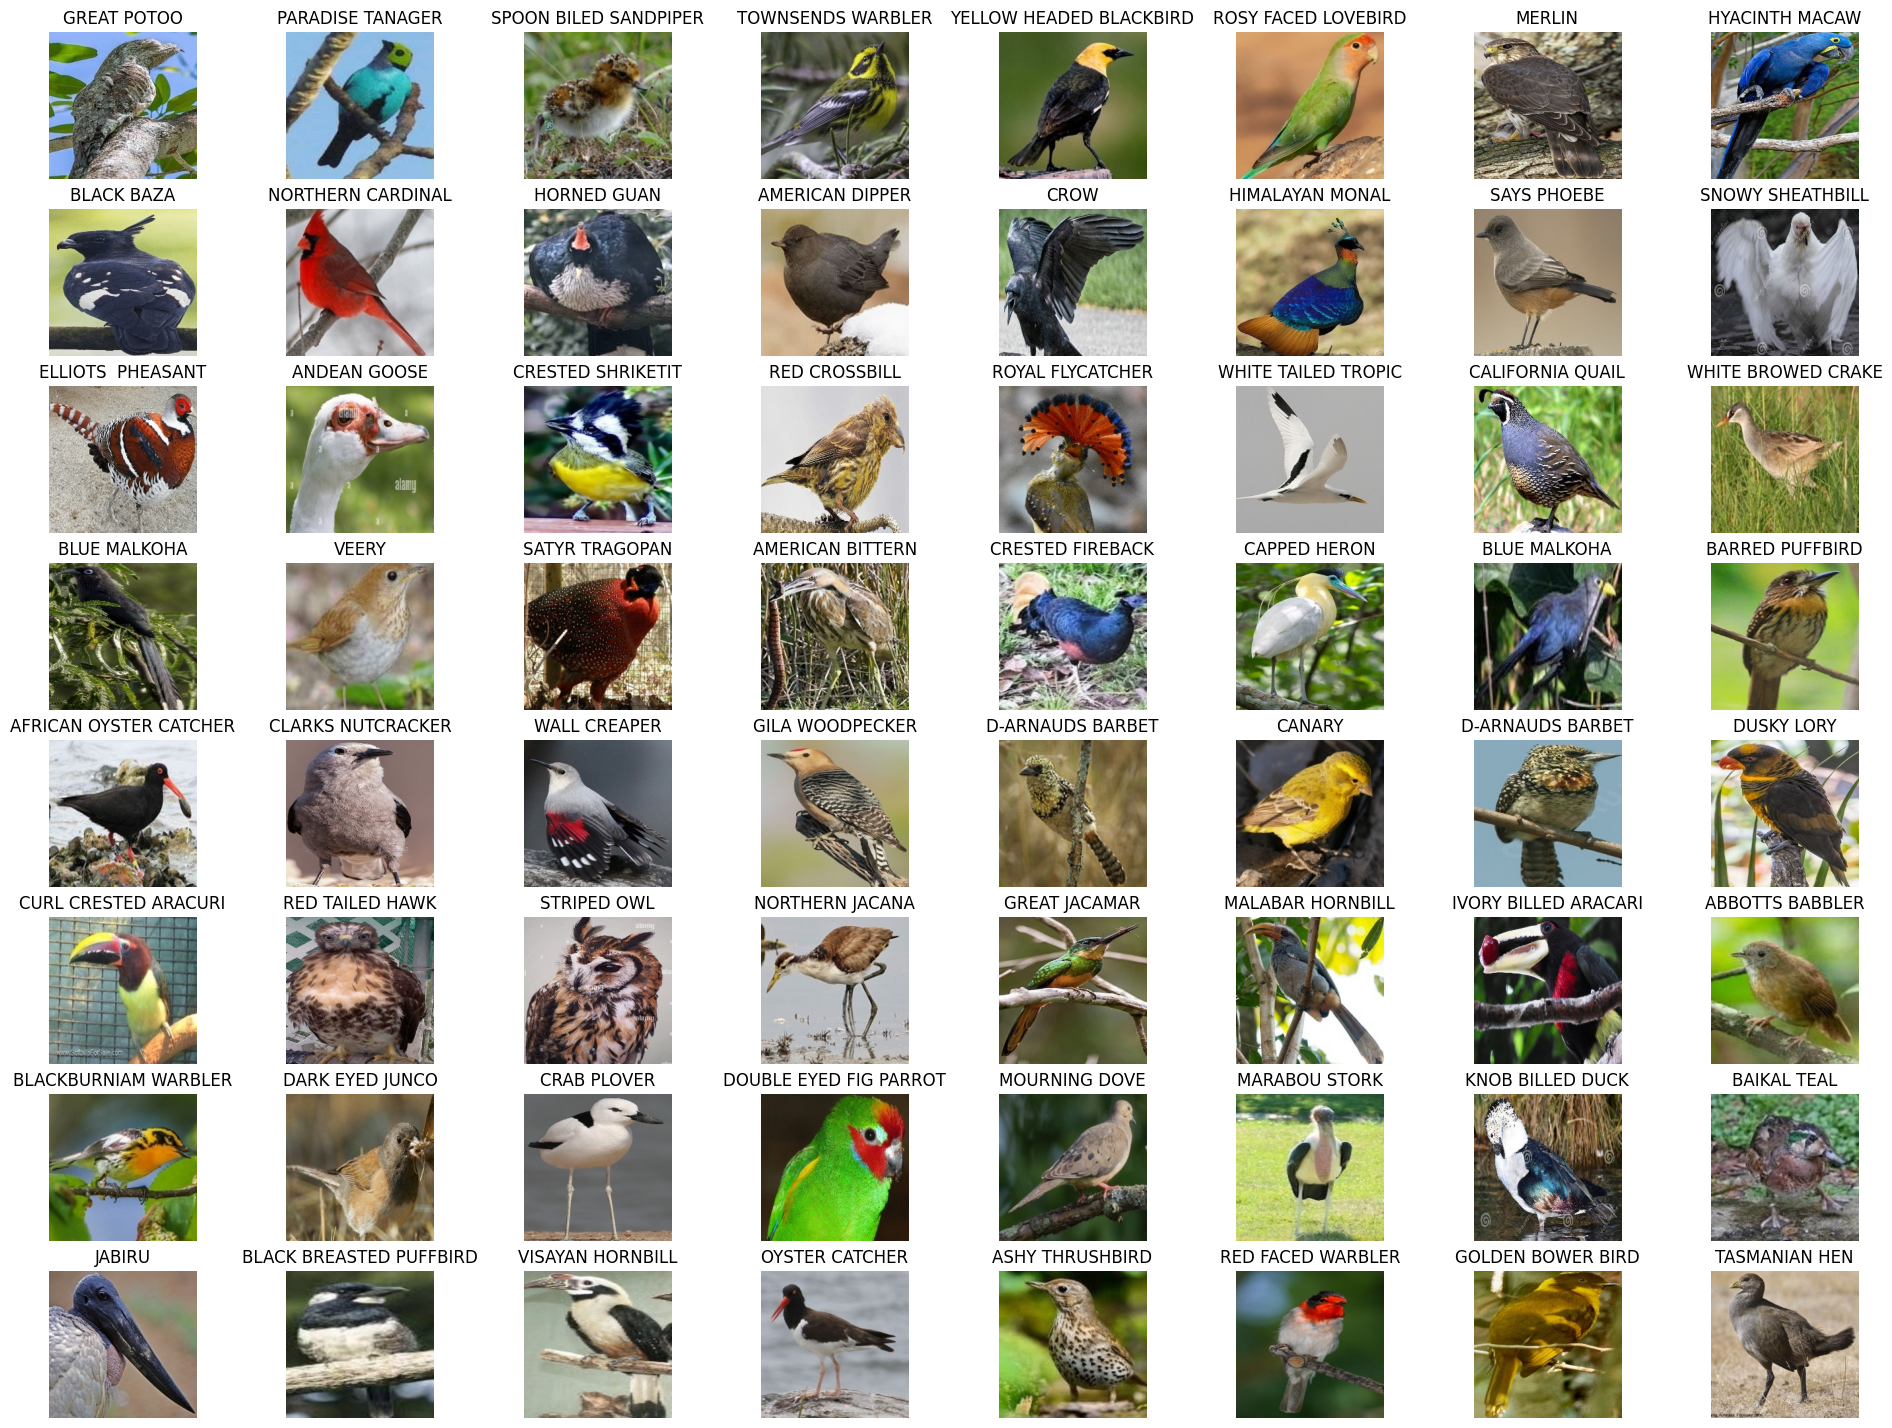

In [ ]:
visualize_dataset(dataloader=train_ds, classes=train_dataset.classes)

### ANN MODEL

In [ ]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = len(train_dataset.classes)
input_features = 3 * image_size[0] * image_size[1]  # 3 * 224 * 224

class BirdANN(nn.Module):
    def __init__(self, input_features, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),

            nn.Linear(input_features, 256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(128, num_classes)
            # Softmax EKLENMEZ:
            # CrossEntropyLoss bunu logits üzerinden kendisi uygular.
        )

    def forward(self, x):
        return self.network(x)


# Model
ann_model = BirdANN(
    input_features=input_features,
    num_classes=num_classes
).to(device)

# Loss: etiketler [batch_size] biçimindeki sınıf indeksleri
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    ann_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

print(f"Sınıf sayısı: {num_classes}")
print(f"Model cihazı: {device}")

Sınıf sayısı: 525
Model cihazı: cuda


In [ ]:
epochs = 10

for epoch in range(epochs):
    ann_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_ds:
        images = images.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()

        outputs = ann_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(train_ds)
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Train Accuracy: %{epoch_accuracy:.2f}"
    )

Epoch [1/10] | Loss: 6.3200 | Train Accuracy: %0.25
Epoch [2/10] | Loss: 6.2604 | Train Accuracy: %0.32
Epoch [3/10] | Loss: 6.2601 | Train Accuracy: %0.28
Epoch [4/10] | Loss: 6.2612 | Train Accuracy: %0.28


KeyboardInterrupt: 

In [ ]:
summary(
    ann_model,
    input_size=(1, 3, 224, 224),  # batch, channel, height, width
    device=str(device)
)

Layer (type:depth-idx)                   Output Shape              Param #
BirdANN                                  [1, 525]                  --
├─Sequential: 1-1                        [1, 525]                  --
│    └─Flatten: 2-1                      [1, 150528]               --
│    └─Linear: 2-2                       [1, 256]                  38,535,424
│    └─ReLU: 2-3                         [1, 256]                  --
│    └─Dropout: 2-4                      [1, 256]                  --
│    └─Linear: 2-5                       [1, 128]                  32,896
│    └─ReLU: 2-6                         [1, 128]                  --
│    └─Dropout: 2-7                      [1, 128]                  --
│    └─Linear: 2-8                       [1, 525]                  67,725
Total params: 38,636,045
Trainable params: 38,636,045
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 38.64
Input size (MB): 0.60
Forward/backward pass size (MB): 0.01
Params size (MB): 154.54
Estim

Multilabel classification olursa, sonda sigmoid kullanılır.

### BASIC CNN MODEL

In [ ]:
class BasicBirdCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Girdi: 3 x 224 x 224
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3),
            # 16 x 74 x 74

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3),
            # 32 x 24 x 24

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 64 x 12 x 12

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            # 128 x 6 x 6

            nn.AdaptiveAvgPool2d((1, 1))
            # GlobalAveragePooling2D karşılığı: 128 x 1 x 1
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, num_classes)
            # Softmax yok; CrossEntropyLoss logits kullanır.
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [ ]:
cnn_model = BasicBirdCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    cnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
!pip install torchinfo -q

In [ ]:
epochs = 5

for epoch in range(epochs):
    cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_ds:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad()
        outputs = cnn_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct += (outputs.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Loss: {running_loss / len(train_ds):.4f} | "
        f"Accuracy: %{100 * correct / total:.2f}"
    )

Epoch [1/5] | Loss: 5.8095 | Accuracy: %1.49
Epoch [2/5] | Loss: 4.8860 | Accuracy: %7.69
Epoch [3/5] | Loss: 4.3512 | Accuracy: %14.41


KeyboardInterrupt: 

In [ ]:
from torchinfo import summary

summary(
    cnn_model,
    input_size=(1, 3, 224, 224),  # batch, channel, height, width
    device=str(device)
)

Layer (type:depth-idx)                   Output Shape              Param #
BasicBirdCNN                             [1, 525]                  --
├─Sequential: 1-1                        [1, 128, 1, 1]            --
│    └─Conv2d: 2-1                       [1, 16, 224, 224]         448
│    └─ReLU: 2-2                         [1, 16, 224, 224]         --
│    └─MaxPool2d: 2-3                    [1, 16, 74, 74]           --
│    └─Conv2d: 2-4                       [1, 32, 74, 74]           4,640
│    └─ReLU: 2-5                         [1, 32, 74, 74]           --
│    └─MaxPool2d: 2-6                    [1, 32, 24, 24]           --
│    └─Conv2d: 2-7                       [1, 64, 24, 24]           18,496
│    └─ReLU: 2-8                         [1, 64, 24, 24]           --
│    └─MaxPool2d: 2-9                    [1, 64, 12, 12]           --
│    └─Conv2d: 2-10                      [1, 128, 12, 12]          73,856
│    └─ReLU: 2-11                        [1, 128, 12, 12]          --
│  

Burada CNN'in gücünü görmüş oluyoruz. ANN ile milyonlarca paramete ile çalışıken yerinde sayan model, CNN ile sadece 165 bin parametre ile öğrenmeye başladı.

### Skip Connection CNN

In [ ]:
class ConvBN(nn.Module):
    def __init__(self, in_channels, filters, kernel_size=3):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Conv2d(
                in_channels,
                filters,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.BatchNorm2d(filters),
            nn.SiLU()  # Swish aktivasyonu
        )

    def forward(self, x):
        return self.layers(x)

In [ ]:
class SkipConnection(nn.Module):
    def __init__(self, in_channels, filters, kernel_size=3):
        super().__init__()

        self.conv1 = ConvBN(in_channels, filters, kernel_size)
        self.conv2 = ConvBN(filters, filters, kernel_size)

    def forward(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)

        # Keras Concatenate() karşılığı
        return torch.cat([x, inputs], dim=1)

In [ ]:
class DownsamplingConv(nn.Module):
    def __init__(self, in_channels, filters, kernel_size=3):
        super().__init__()

        self.conv1 = ConvBN(in_channels, filters, kernel_size)
        self.conv2 = ConvBN(filters, filters, kernel_size)

        # Keras AveragePooling2D((3, 3)) karşılığı
        self.pool = nn.AvgPool2d(kernel_size=3, stride=3)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        return self.pool(x)

In [ ]:
class ResCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # Girdi: 3 x 224 x 224
        self.skip1 = SkipConnection(3, 16)
        # Çıkış: 16 + 3 = 19 kanal

        self.skip2 = SkipConnection(19, 32)
        # Çıkış: 32 + 19 = 51 kanal

        self.downsample1 = DownsamplingConv(51, 32)
        # Çıkış: 32 kanal, görüntü boyutu küçülür

        self.skip3 = SkipConnection(32, 64)
        # Çıkış: 64 + 32 = 96 kanal

        self.skip4 = SkipConnection(96, 64)
        # Çıkış: 64 + 96 = 160 kanal

        self.downsample2 = DownsamplingConv(160, 64)
        # Çıkış: 64 kanal

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.flatten = nn.Flatten()

        # activation=None karşılığı: logits üretir
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.skip1(x)
        x = self.skip2(x)
        x = self.downsample1(x)

        x = self.skip3(x)
        x = self.skip4(x)
        x = self.downsample2(x)

        x = self.global_pool(x)
        x = self.flatten(x)

        return self.classifier(x)

In [ ]:
res_cnn_model = ResCNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    res_cnn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

In [ ]:
summary(
    res_cnn_model,
    input_size=(1, 3, 224, 224),
    device=str(device)
)

Layer (type:depth-idx)                   Output Shape              Param #
ResCNN                                   [1, 525]                  --
├─SkipConnection: 1-1                    [1, 19, 224, 224]         --
│    └─ConvBN: 2-1                       [1, 16, 224, 224]         --
│    │    └─Sequential: 3-1              [1, 16, 224, 224]         480
│    └─ConvBN: 2-2                       [1, 16, 224, 224]         --
│    │    └─Sequential: 3-2              [1, 16, 224, 224]         2,352
├─SkipConnection: 1-2                    [1, 51, 224, 224]         --
│    └─ConvBN: 2-3                       [1, 32, 224, 224]         --
│    │    └─Sequential: 3-3              [1, 32, 224, 224]         5,568
│    └─ConvBN: 2-4                       [1, 32, 224, 224]         --
│    │    └─Sequential: 3-4              [1, 32, 224, 224]         9,312
├─DownsamplingConv: 1-3                  [1, 32, 74, 74]           --
│    └─ConvBN: 2-5                       [1, 32, 224, 224]         --
│    

In [ ]:
total_params = sum(p.numel() for p in res_cnn_model.parameters())
print(f"Toplam parametre: {total_params:,}")

Toplam parametre: 353,565


In [ ]:
!pip install torchview graphviz -q

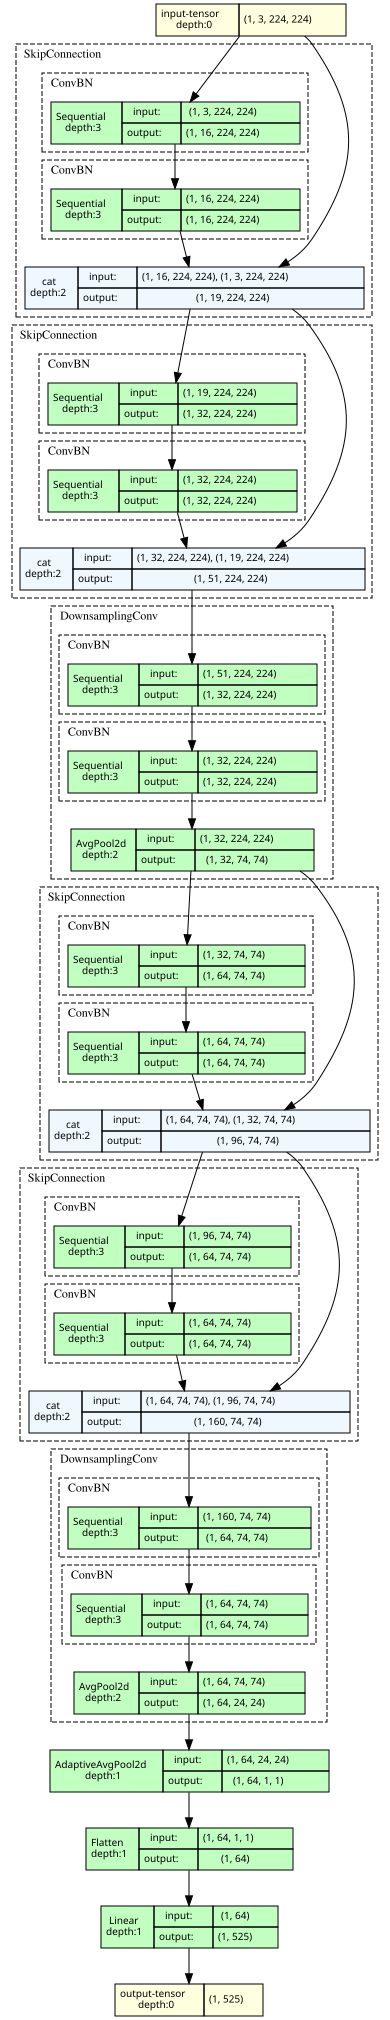

In [ ]:
from torchview import draw_graph

model_graph = draw_graph(
    res_cnn_model,
    input_size=(1, 3, 224, 224),  # batch, kanal, yükseklik, genişlik
    expand_nested=True,
    device=str(device)
)

model_graph.visual_graph

In [ ]:
from tqdm.auto import tqdm
import time

epochs = 5

for epoch in range(epochs):
    start_time = time.time()

    res_cnn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        train_ds,
        desc=f"Epoch {epoch + 1}/{epochs}"
    )

    for images, labels in progress_bar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True).long()

        optimizer.zero_grad()

        outputs = res_cnn_model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"%{100 * correct / total:.2f}"
        )

    epoch_loss = running_loss / len(train_ds)
    epoch_accuracy = 100 * correct / total
    epoch_time = (time.time() - start_time) / 60

    print(
        f"Epoch [{epoch + 1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: %{epoch_accuracy:.2f} | "
        f"Süre: {epoch_time:.2f} dk"
    )

Epoch 1/5:   0%|          | 0/1323 [00:00<?, ?it/s]

Epoch [1/5] | Loss: 5.5328 | Accuracy: %3.35 | Süre: 19.19 dk


Epoch 2/5:   0%|          | 0/1323 [00:00<?, ?it/s]

KeyboardInterrupt: 